# 2.2 Calibration as optimization

Every Earth system model carries parameters, these can be physically meaningful and measureable or simply constants fit to data. 
Here we examine the parameter for the 
diffusivity $D$ and the ice albedo $\alpha_i$ from the Budyko-Sellers model as used in section 2.1. Choosing the values of these parameters to match observations is
**calibration** (the term *tuning* is also used). With
a differentiable model, calibration becomes ordinary optimization: write down a misfit
between model and observations, and perform gradient descent to find the parameter setting that minimizes the misfit.

This chapter calibrates the Budyko–Sellers model in a **perfect-model experiment**: the
"observations" are produced by the model itself with known parameters, plus noise. Since the answer is known we can evaluate the method. 

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
!pip install -q optax equinox diffrax

In [3]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

## Synthetic observations

Truth: the default parameters ($D = 0.48$, $\alpha_i = 0.62$). The observations are the
truth's equilibrium zonal-mean temperature profile with 1 K of independent noise at
each latitude, a simplification of an observed climatology:

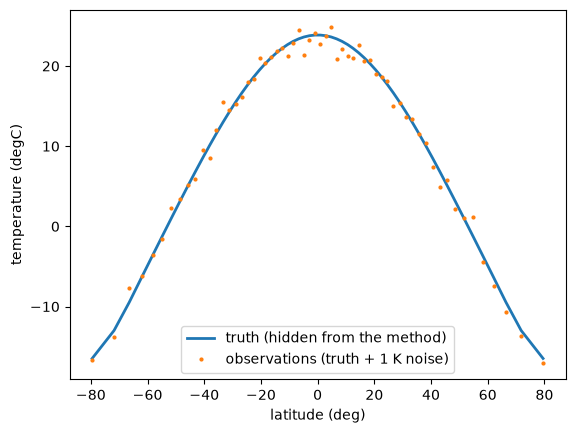

In [4]:
true_params = dict(default_params)
key = jax.random.key(0)
T_true = integrate(T_start, true_params)
T_obs = T_true + 1.0 * jax.random.normal(key, T_true.shape) # add noise

plt.plot(lat, T_true, lw=2, label="truth (hidden from the method)")
plt.plot(lat, T_obs, ".", ms=4, label="observations (truth + 1 K noise)")
plt.xlabel("latitude (deg)"); plt.ylabel("temperature (degC)"); plt.legend()
plt.show()

## Misfit and its gradient

The misfit is a mean-square difference between the model's equilibrium profile and the
observations, as a function of the two parameters being calibrated. Before any
optimization let's check the gradient.

In [5]:
def loss(theta):
    p = dict(true_params, D=theta[0], albedo_ice=theta[1])
    T = integrate(T_start, p)
    return jnp.mean((T - T_obs) ** 2)

theta0 = jnp.array([0.40, 0.55])          # a deliberately wrong first guess
g = jax.grad(loss)(theta0)
for i, name in enumerate(["D", "albedo_ice"]):
    bump = jnp.zeros(2).at[i].set(1e-5)
    fd = (loss(theta0 + bump) - loss(theta0 - bump)) / 2e-5
    print(f"dJ/d({name}):  autodiff {float(g[i]):9.4f}   finite difference {float(fd):9.4f}")

dJ/d(D):  autodiff  -71.3768   finite difference  -71.3768
dJ/d(albedo_ice):  autodiff   42.3577   finite difference   42.3577


In [8]:
p = dict(true_params, D=theta0[0], albedo_ice=theta0[1])
T = integrate(T_start, p)

In [10]:
jnp.mean((T - T_obs) ** 2)

Array(2.75355014, dtype=float64)

## Descending

We now minimize the loss with gradient descent, using an optimizer from `optax`, the
standard JAX optimization library. Each iteration does three things:

1. runs the full 30-year spin-up with the current parameter values,
2. computes the loss against the target, and
3. backpropagates through the entire spin-up to get the gradient of the loss with
   respect to both parameters.

We use Adam rather than plain gradient descent because the two parameters differ in
scale by orders of magnitude, so a single fixed step size would be too large for one or
too small for the other. Adam rescales each parameter's update by a running estimate of
its gradient magnitude, which removes the need to normalize or precondition the
parameters by hand. The step size decays over iterations so that early steps move
quickly and later steps settle near the minimum instead of oscillating around it.

recovered: D = 0.472, albedo_ice = 0.605
truth:     D = 0.480, albedo_ice = 0.620
final loss 1.179 vs observation noise variance 1.0


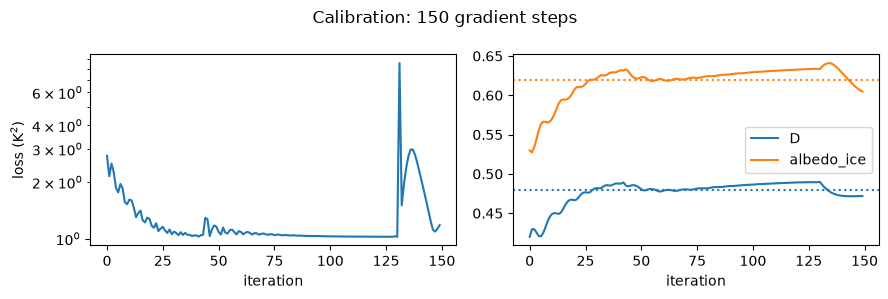

In [11]:
import optax

# optimizer setup
#The learning rate starts at 0.02 and halves every 50 steps
opt = optax.adam(optax.exponential_decay(2e-2, transition_steps=50, decay_rate=0.5)) 
state = opt.init(theta0)

#jax.value_and_grad builds one function that returns both the loss and its gradient with respect to theta, 
#so the forward spin-up isn't run twice. jax.jit compiles it with XLA. 
#The first call is slow because of tracing and compilation, and every later call is fast. 
value_and_grad = jax.jit(jax.value_and_grad(loss))

# Optimization loop
theta, history = theta0, []
for i in range(150):
    L, g = value_and_grad(theta) #evaluates the loss and gradient at the current parameters
    updates, state = opt.update(g, state) # Adam turns the raw gradient into a step 
    theta = optax.apply_updates(theta, updates) #apply_updates adds the step to theta, which is effectively theta + updates
    history.append([float(L), float(theta[0]), float(theta[1])]) # The loss and both parameters are recorded

import numpy as np
history = np.array(history)
print(f"recovered: D = {theta[0]:.3f}, albedo_ice = {theta[1]:.3f}")
print(f"truth:     D = {true_params['D']:.3f}, albedo_ice = {true_params['albedo_ice']:.3f}")
print(f"final loss {history[-1,0]:.3f} vs observation noise variance 1.0")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.semilogy(history[:, 0]); ax1.set_xlabel("iteration"); ax1.set_ylabel("loss (K$^2$)")
ax2.plot(history[:, 1], label="D"); ax2.plot(history[:, 2], label="albedo_ice")
ax2.axhline(0.48, color="C0", ls=":"); ax2.axhline(0.62, color="C1", ls=":")
ax2.set_xlabel("iteration"); ax2.legend()
fig.suptitle("Calibration: 150 gradient steps"); plt.tight_layout(); plt.show()

Both parameters are recovered to a few percent after 150 iterations. 
The loss flattens just above the observation-noise variance (1 K²). A loss well
above the noise floor means the model cannot fit the data; a loss *below* it means the
method has started fitting the noise. Knowing where the floor is turns the loss value
itself into a diagnostic.

## The loss landscape

Since this is a simple model with only two parameters we can evaluate the loss
everywhere. The loss landscape explains the optimizer's behavior and previews concepts that
matter when there are many parameters:

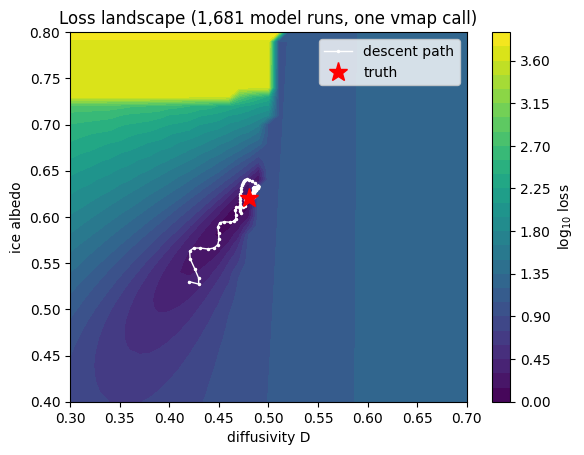

In [6]:
D_grid = jnp.linspace(0.30, 0.70, 41)
ai_grid = jnp.linspace(0.40, 0.80, 41)
DD, AI = jnp.meshgrid(D_grid, ai_grid)
L_grid = jax.jit(jax.vmap(jax.vmap(lambda d, a: loss(jnp.array([d, a])))))(DD, AI)

plt.contourf(DD, AI, jnp.log10(L_grid), levels=25)
plt.colorbar(label="log$_{10}$ loss")
plt.plot(history[:, 1], history[:, 2], "w.-", ms=3, lw=1, label="descent path")
plt.plot(0.48, 0.62, "r*", ms=14, label="truth")
plt.xlabel("diffusivity D"); plt.ylabel("ice albedo")
plt.legend(); plt.title("Loss landscape (1,681 model runs, one vmap call)")
plt.show()

Two features to highlight, first, the minimum sits in a curved **valley**: along its floor,
increasing $D$ (more heat to the pole, smaller ice cap) can be partly traded against
increasing $\alpha_i$ (brighter ice) with little change in misfit. This *parameter
compensation* is ubiquitous in real model tuning, and in high-dimensions is why converged parameters should never be over-interpreted individually. Second, the landscape steepens dramatically toward low $D$ / high
$\alpha_i$: there the ice cap runs away toward an ice-covered planet — a reminder that
parameter space contains different climate *regimes*, not just different fits.

## Gradients or ensembles?

The community's standard tools for this problem are either ensemble Kalman methods or perturbed parameter ensembles.  These estimate the descent direction statistically from tens to hundreds of perturbed model runs, or from emulators of the PPE. A comparison of the features:

- **Cost.** A gradient step costs a few model runs regardless of parameter count;
  ensemble methods need ensembles comparable to the number of effective parameters.
  With two parameters this is not relevant but with 30 parameters in an atmospheric model ensemble methods become computationally expensive of infeasible. For a $10^5$-parameter neural network closure (Chapter 2.4) there is no ensemble alternative.
- **Robustness.** Ensembles average over roughness and need no derivative to exist;
  gradients require the loss to be smooth, which Chapters 3.1 and 3.3 show is a real
  constraint (chaos, thresholds).
- **Uncertainty.** An ensemble gives a spread for free; a gradient gives a point
  estimate (though the loss curvature recovers local
  uncertainty).
- **Local minima.** Gradient descent only sees the local slope. It moves downhill from
  its starting point and stops wherever the gradient reaches zero, with no information
  about whether a lower valley exists elsewhere. Earth system model losses are often
  non-convex: compensating parameters (e.g., too-strong mixing offset by too-bright ice)
  and threshold behavior create multiple basins that each fit the observations
  reasonably well. The danger is that a local minimum looks like success. The loss has
  stopped decreasing and the gradient is near zero, but the recovered parameters can be
  physically wrong, and a different starting guess would give a different answer.
  Ensembles and PPEs sample across the full prior range, so they can reveal multiple
  plausible regions instead of committing to the nearest one. Common remedies for
  gradient methods are multiple random starts or initializing from the best members of
  a PPE or emulator search.

**Exercises.**
1. Calibrate with observations only equatorward of 60° (mask the loss). Where does the
   recovered $\alpha_i$ end up, and why does the valley direction predict this?
2. Add $A$ (the longwave constant) as a third parameter. Does the noise-floor loss
   change? Are the parameters still identifiable?
3. Replace Adam with plain gradient descent (`optax.sgd`). What learning rate is
   needed, and why is it so different in the two parameter directions?